<a href="https://colab.research.google.com/github/harsha19102003/Restaurant_Tipping_Behaviour_Analysis/blob/main/BCT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Restaurant Tipping Behavior Analysis**

### **Objective**
This project analyzes tipping behavior in restaurants using the Seaborn Tips dataset.
The goal is to understand how factors such as bill amount, gender, smoking status, and day of the week affect tipping patterns.

The analysis includes:
- Data wrangling
- Exploratory data analysis
- Statistical testing (ANOVA)
- Regression modeling
- Data visualization

## **Import Required Libraries**

The following Python libraries are used for data analysis and visualization.

- **pandas** → data manipulation
- **numpy** → numerical operations
- **seaborn** → statistical visualization
- **matplotlib** → plotting
- **plotly** → interactive visualizations
- **scipy** → statistical testing
- **sklearn** → regression modeling

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats
from sklearn.linear_model import LinearRegression

## **Load the Dataset**

The dataset used in this analysis is the **Tips dataset** from the Seaborn library.

It contains information about restaurant bills and tips including:
- total bill amount
- tip amount
- customer gender
- smoking status
- day of the visit
- meal time
- number of people at the table

In [ ]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## **Dataset Overview**

Before analyzing the data, we examine the dataset structure to understand:
- number of rows
- column data types
- available features

In [ ]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## **Data Wrangling**

To better analyze tipping behavior, we create a new feature called **tip_percent**.

Tip Percentage = (Tip Amount / Total Bill) × 100

This helps compare tipping behavior across different bill sizes.

In [ ]:
tips["tip_percent"] = (tips["tip"] / tips["total_bill"]) * 100
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


## **Distribution of Tip Amounts**

We visualize how tips are distributed across all restaurant bills.
This helps identify typical tipping values and possible outliers.

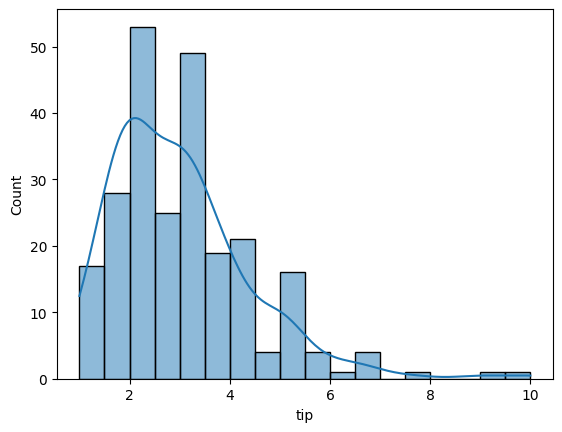

In [ ]:
sns.histplot(tips["tip"], kde=True)
plt.show()

## **Tip Percentage by Gender**

This visualization compares tipping percentages between male and female customers.
The violin plot shows both the distribution and density of tipping behavior.

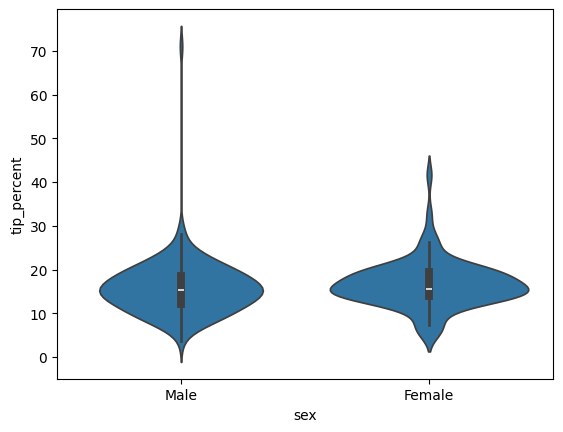

In [ ]:
sns.violinplot(x="sex", y="tip_percent", data=tips)
plt.show()

## **Tip Percentage by Day**

This visualization explores how tipping behavior changes across different days of the week.

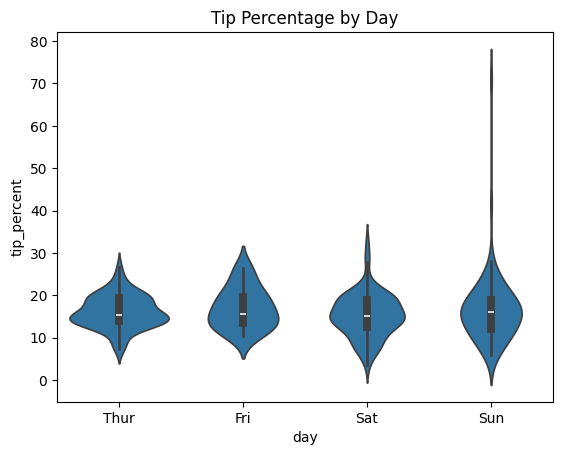

In [ ]:
sns.violinplot(x="day", y="tip_percent", data=tips)
plt.title("Tip Percentage by Day")
plt.show()

## **Pairwise Relationship Analysis**

The pairplot visualizes relationships between numerical variables such as:
- total bill
- tip
- tip percentage
- party size

This helps identify correlations between variables.

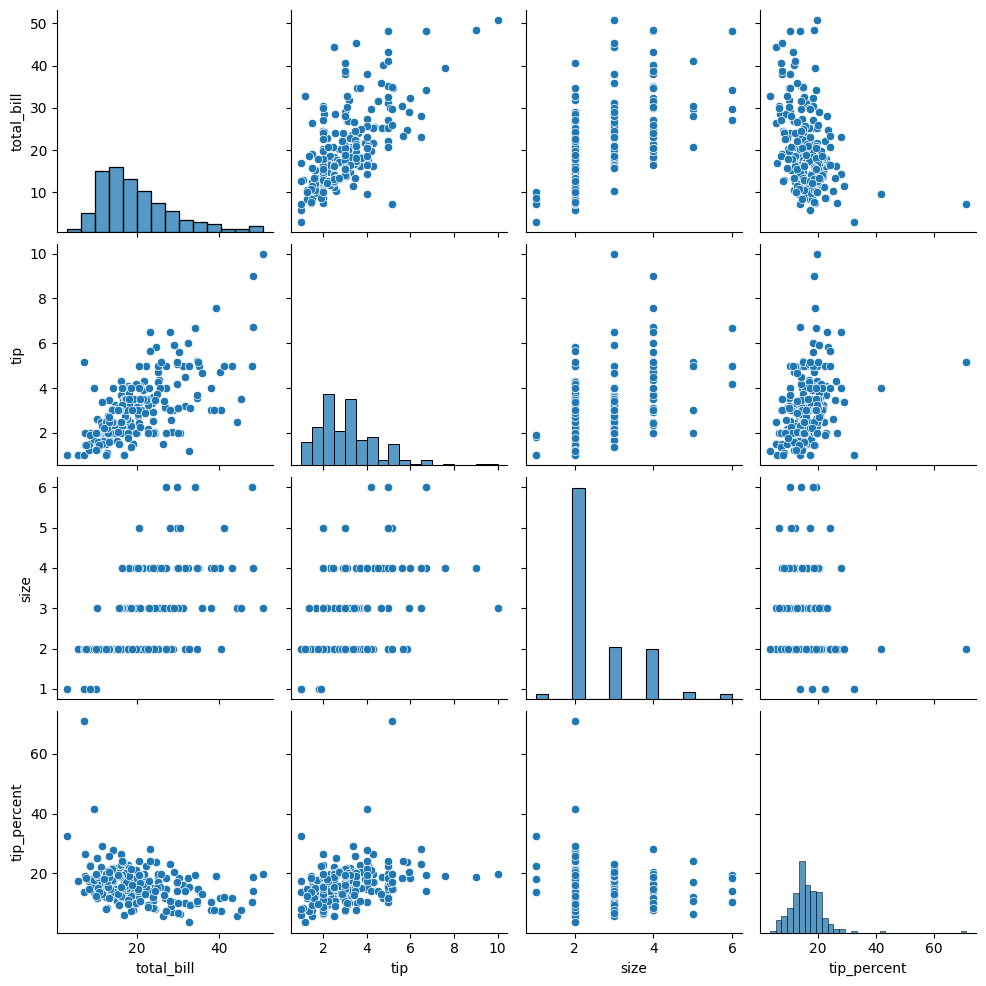

In [ ]:
sns.pairplot(tips)
plt.show()

## **Correlation Analysis**

Correlation analysis helps identify **relationships between numerical variables in the dataset.**

A correlation heatmap is used to **visualize the strength of relationships between variables such as total bill, tip amount, and party size.**

Values close to **1** indicate **strong positive correlation**, while values close to **0** indicate **weak relationships**.

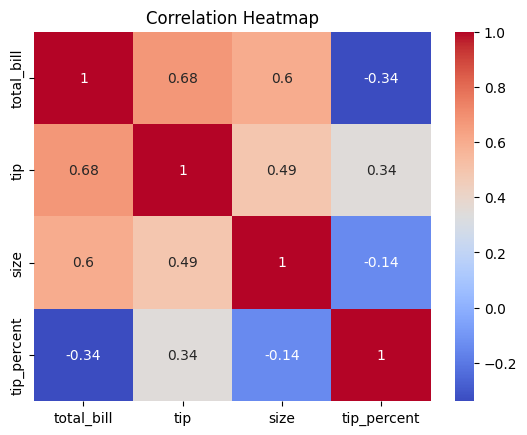

In [ ]:
corr = tips.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that **total_bill and tip have a strong positive correlation**, meaning that larger bills generally result in larger tips.

## Statistical Analysis: **ANOVA**

Analysis of Variance **(ANOVA)** is used to determine whether there are statistically significant differences between groups.

We compare tipping percentages across:
- Gender
- Smoker status
- Day of the week

If the **p-value** is less than **0.05**, the difference is considered **statistically significant**.

In [ ]:
male = tips[tips["sex"]=="Male"]["tip_percent"]
female = tips[tips["sex"]=="Female"]["tip_percent"]

stats.f_oneway(male, female)

F_onewayResult(statistic=np.float64(1.1737495515748593), pvalue=np.float64(0.279710384960558))

In [ ]:
smoker = tips[tips["smoker"]=="Yes"]["tip_percent"]
nonsmoker = tips[tips["smoker"]=="No"]["tip_percent"]

stats.f_oneway(smoker, nonsmoker)

F_onewayResult(statistic=np.float64(0.23008263761861872), pvalue=np.float64(0.6318957776878595))

In [ ]:
thur = tips[tips["day"]=="Thur"]["tip_percent"]
fri = tips[tips["day"]=="Fri"]["tip_percent"]
sat = tips[tips["day"]=="Sat"]["tip_percent"]
sun = tips[tips["day"]=="Sun"]["tip_percent"]

stats.f_oneway(thur, fri, sat, sun)

F_onewayResult(statistic=np.float64(0.848004878913012), pvalue=np.float64(0.46884089923526473))

## **Regression Analysis**

**Linear regression** is used to **model the relationship between the total bill and the tip amount.**

The goal is to determine whether **larger bills lead to larger tips and to build a model that predicts tip amount based on bill size**.

In [ ]:
X = tips[["total_bill"]]
y = tips["tip"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 0.9202696135546731
Coefficient: 0.10502451738435337


## **Tip Prediction Example**

Using the trained regression model, we can **estimate the expected tip for a given bill amount.**

For example, we predict the tip for a $40 bill.

In [ ]:
model.predict([[40]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([5.12125031])

## **Interactive Visualization**

We use **Plotly** to create an interactive bar chart showing the average tip amount for each day of the week.

In [ ]:
avg_tip = tips.groupby("day")["tip"].mean().reset_index()

fig = px.bar(
    avg_tip,
    x="day",
    y="tip",
    color="day",
    title="Average Tip by Day"
)

fig.show()

/tmp/ipykernel_679/2955521693.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The analysis shows that tipping behavior is positively related to the total bill amount.
Statistical tests reveal differences in tipping patterns across different customer groups and days of the week.
Regression analysis confirms that larger bills tend to generate larger tips.

# **Average Tip by Gender and Day**

This section analyzes the average tip amount based on both **day of the week** and **customer gender**.

Group analysis helps **identify patterns that may not be visible in individual observations**.

In [ ]:
group_analysis = tips.groupby(["day","sex"])["tip"].mean().reset_index()

group_analysis

/tmp/ipykernel_679/220535348.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,day,sex,tip
0,Thur,Male,2.980333
1,Thur,Female,2.575625
2,Fri,Male,2.693000
3,Fri,Female,2.781111
4,Sat,Male,3.083898
5,Sat,Female,2.801786
6,Sun,Male,3.220345
7,Sun,Female,3.367222


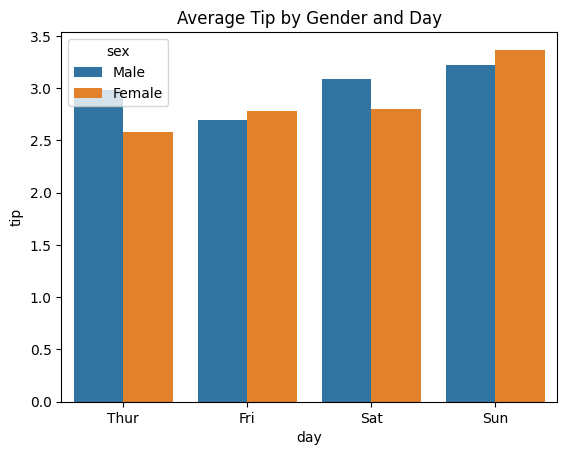

In [ ]:
sns.barplot(x="day", y="tip", hue="sex", data=group_analysis)

plt.title("Average Tip by Gender and Day")
plt.show()

This chart compares **tipping patterns** across different days and genders.
It helps highlight **differences in average tipping behavior across groups**.

## **Key Insights**

From the analysis, several key patterns emerge:

• Tip amounts increase as the total bill increases.

• Certain days show slightly higher average tipping  
• The regression model confirms a positive relationship between bill size and tip  
• Group analysis reveals small variations in tipping behavior across customer groups

## **Conclusion**

The analysis reveals several insights into **restaurant tipping behavior:**

1. **Tip amounts increase as the total bill increases.**
2. **Certain days of the week show slightly different tipping patterns.**
3. **Regression analysis confirms a positive relationship between bill size and tip amount.**
4. **Statistical tests help identify whether tipping differences between groups are significant.**

Overall, the results demonstrate how data analysis techniques can be used to understand customer behavior in restaurant settings.